In [13]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
from scipy.io import arff
from imblearn.under_sampling import RandomUnderSampler
from python_scripts.preprocessing import *
#from sdv.single_table import CTGANSynthesizer
#from sdv.metadata import SingleTableMetadata
import warnings
warnings.simplefilter(action='ignore')

Loading dataset : https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [14]:
# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Emilien JEMELEN\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


In [15]:
df = pd.read_csv('C:/Users/Emilien JEMELEN/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2/data.csv')
df['diagnosis'].replace({'M':1, 'B':0}, inplace=True)
df.drop(['id','Unnamed: 32'], axis=1, inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
print(df.shape)
print('Proportion of 1s:', np.round(df.diagnosis.sum()/df.shape[0],2))

(569, 31)
Proportion of 1s: 0.37


#### some preprocessing

In [ ]:
X = df.drop(['diagnosis'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# If you want a DataFrame back
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

Y = df.diagnosis

In [18]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [19]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=2/3, random_state=0, stratify=Y)

## <font color='yellow'> logistic regression

In [20]:
model = LogisticRegression(random_state=0, max_iter=100)
model.fit(X_train, Y_train)

LogisticRegression(random_state=0)

In [21]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       238
           1       0.92      0.95      0.93       142

    accuracy                           0.95       380
   macro avg       0.94      0.95      0.95       380
weighted avg       0.95      0.95      0.95       380

Test Accuracy: 0.95


### Retrieving $\kappa_f$ confidence function

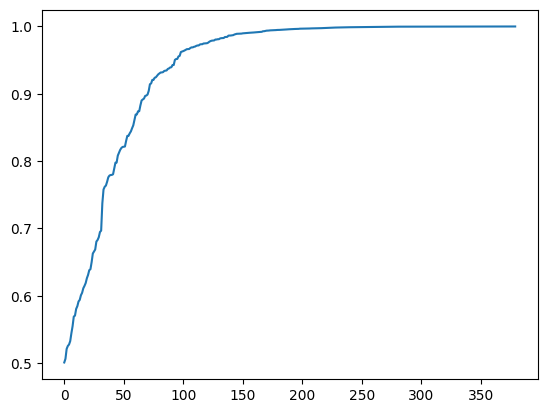

In [22]:
y_true = Y_test
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [ ]:
sgp_df = pd.DataFrame({'y_true': y_true,
                       'y_pred': y_pred,
                       'kappa': kappa}).sort_values('kappa')
sgp_df

,y_true,y_pred,kappa
340,0,1,0.500951
526,0,1,0.506373
414,1,0,0.521076
541,0,0,0.525504
496,0,0,0.527598
...,...,...,...
236,1,1,1.000000
82,1,1,1.000000
108,1,1,1.000000
461,1,1,1.000000


In [ ]:
pickle.dump(sgp_df, open('sgp_set_log_reg','wb'))